In [1]:
%load_ext autoreload
%autoreload 2

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.interpolate import RegularGridInterpolator
import seaborn as sns
from mpl_toolkits.axes_grid1.inset_locator import mark_inset

from itertools import product
import matplotlib.colors as mcolors
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

from wrf_io import *

from MITRotor import IEA15MW

import seaborn as sns

from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import (
    RBF,
    Matern,
    RationalQuadratic,
    ExpSineSquared,
    WhiteKernel,
    DotProduct,
)
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

In [7]:
fontsize = 24
plt.rcParams['xtick.labelsize'] = 20 
plt.rcParams['ytick.labelsize'] = 20 

plt.rcParams.update({
    'text.usetex': True,
    'text.latex.preamble': r'\usepackage{amsfonts}'
})

In [8]:
casenames = [
r's000_vn200',
r's000_vn100',
r's000_vn050',
r's000_vn025',
r's000_v000',
r's000_v025',
r's000_v050',
r's000_v100',
r's000_v200',
]

In [10]:
par_path = '/Users/stormmata/Downloads/10MW/gad_sweep/parameters.pkl'

local_path = '/Users/stormmata/Downloads/15MW'

params = postproc.load_params(par_path)
data   = postproc.extract_sounding(params=params, local=True, path=local_path)
wrfles = postproc.load_data(params=params, casenames=casenames, local=True, path=local_path)

allocation     : ATM170028
partition      : spr
runtime        : 48:00:00
system         : stampede
num_nodes      : 2
exclude_time   : 10
save_interval  : 10
base_dir       : /scratch/09909/smata/wrf_les_sweep/runs/10MW/rate
wrf_path       : /work2/09909/smata/stampede3/WRF_LES
template_path  : /scratch/09909/smata/wrf_les_sweep/templates
turb_model     : iea10MW
rotor_model    : GAD
slice_loc      : 1
print_table    : True
plot_outer     : True
save_outer     : False
outer_align    : False
plot_inner     : True
save_inner     : False
save_both      : False
outer_pad      : 75
plot_profiles  : True
save_profiles  : True
batch_submit   : True
prof_type      : Idealized
shear_type     : Rate
shear          : [-0.03, -0.02, -0.01, 0, 0.01, 0.02, 0.03]
veer           : [-0.2, -0.1, -0.05, -0.025, 0, 0.025, 0.05, 0.1, 0.2]
excluded_pairs : []
Ufst           : 7


In [12]:
params['base_dir']   = '/scratch/09909/smata/wrf_les_sweep/runs/15MW/rate'
params['turb_model'] = 'iea15MW'

In [13]:
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C, WhiteKernel


In [14]:
shear_vals = [0,0,0,0,0,0,0,0,0]

veer_vals  = [-0.2,-0.1,-0.05,-0.025,0,0.025,0.05,0.1,0.2]

In [ ]:
Nelm = wrfles[0]['Nelm']
Nsct = wrfles[0]['Nsct']

t = np.linspace(0,2*np.pi,Nsct)
r = np.linspace(0,1,Nelm)

rho = 1.225

z_hh = wrfles[0]['hub_height']

R, T = np.meshgrid(r, t)

X = R * np.sin(T)
Y = (R * np.cos(T)) * wrfles[0]['radius'] + z_hh

wrf_vax      = np.zeros((Nelm, Nsct, len(casenames)),dtype='longdouble')
wrf_vtn      = np.zeros((Nelm, Nsct, len(casenames)),dtype='longdouble')

wrf_vax_real = np.zeros((Nelm, Nsct, len(casenames)),dtype='longdouble')
wrf_vtn_real = np.zeros((Nelm, Nsct, len(casenames)),dtype='longdouble')

wrf_vtn_NR   = np.zeros((Nelm, Nsct, len(casenames)),dtype='longdouble')
wrf_vtn_NR_real= np.zeros((Nelm, Nsct, len(casenames)),dtype='longdouble')

wrf_W        = np.zeros((Nelm, Nsct, len(casenames)),dtype='longdouble')
wrf_W_real   = np.zeros((Nelm, Nsct, len(casenames)),dtype='longdouble')

wrf_CL       = np.zeros((Nelm, Nsct, len(casenames)),dtype='longdouble')
wrf_CD       = np.zeros((Nelm, Nsct, len(casenames)),dtype='longdouble')

wrf_CL_real  = np.zeros((Nelm, Nsct, len(casenames)),dtype='longdouble')
wrf_CD_real  = np.zeros((Nelm, Nsct, len(casenames)),dtype='longdouble')

wrf_L        = np.zeros((Nelm, Nsct, len(casenames)),dtype='longdouble')
wrf_D        = np.zeros((Nelm, Nsct, len(casenames)),dtype='longdouble')

wrf_L_real   = np.zeros((Nelm, Nsct, len(casenames)),dtype='longdouble')
wrf_D_real   = np.zeros((Nelm, Nsct, len(casenames)),dtype='longdouble')

wrf_FN       = np.zeros((Nelm, Nsct, len(casenames)),dtype='longdouble')
wrf_FT       = np.zeros((Nelm, Nsct, len(casenames)),dtype='longdouble')

wrf_FN_real  = np.zeros((Nelm, Nsct, len(casenames)),dtype='longdouble')
wrf_FT_real  = np.zeros((Nelm, Nsct, len(casenames)),dtype='longdouble')

wrf_phi      = np.zeros((Nelm, Nsct, len(casenames)),dtype='longdouble')
wrf_phi_real = np.zeros((Nelm, Nsct, len(casenames)),dtype='longdouble')

wrf_aoa      = np.zeros((Nelm, Nsct, len(casenames)),dtype='longdouble')
wrf_aoa_real = np.zeros((Nelm, Nsct, len(casenames)),dtype='longdouble')

wrf_cax      = np.zeros((Nelm, Nsct, len(casenames)),dtype='longdouble')
# wrf_cot      = np.zeros((Nelm, Nsct, len(casenames)),dtype='longdouble')
# wrf_ind      = np.zeros((Nelm, Nsct, len(casenames)),dtype='longdouble')

wrf_pow      = np.zeros(len(casenames),dtype='longdouble')
wrf_thr      = np.zeros(len(casenames),dtype='longdouble')

wrf_pow_real = np.zeros(len(casenames),dtype='longdouble')
wrf_thr_real = np.zeros(len(casenames),dtype='longdouble')

shapiro      = np.zeros(len(casenames), dtype=float)

Uhub         = np.zeros(len(casenames), dtype=float)

wrf_tsr      = np.zeros(len(casenames), dtype=float)
wrf_omg      = np.zeros(len(casenames), dtype=float)

wrf_cot      = np.zeros(len(casenames), dtype=float)
wrf_ind      = np.zeros(len(casenames), dtype=float)

rotor = IEA15MW()

for count,case in enumerate(casenames):

    # Rotor radius
    R = wrfles[count]['radius']

    # Extract background flow
    u_func = interp1d(data[case][:,0], data[case][:,1], kind='linear')
    v_func = interp1d(data[case][:,0], data[case][:,2], kind='linear')

    # u and v velocity functions
    u_inf = u_func(Y)
    v_inf = v_func(Y)

    # Extract u and v velocity components at the rotor disk
    u_rotor = np.mean(wrfles[count]['shapiroM'][0] * wrfles[count]['u'],axis=0)
    # u_rotor = np.mean(wrfles[count]['u'],axis=0)
    v_rotor = np.mean(wrfles[count]['v'],axis=0)
    w_rotor = np.mean(wrfles[count]['w'],axis=0)

    # Magnitude of wind speed at rotor disk
    U = np.sqrt(u_rotor**2 + v_rotor**2)

    # Local wind misalignment angle at the rotor disk
    wdir = np.atan2(v_rotor,u_rotor)

    # Nondimensional radial positions
    r = wrfles[count]['rOverR']
    r_mat =  (np.ones_like(wdir.T) * r).T

    # Azimuthal coordinates
    theta = np.linspace(0, 2*np.pi, wrfles[count]['Nsct'])

    # Freestream wind speed at hub height
    U_hub = np.sqrt(u_func(z_hh)**2 + v_func(z_hh)**2)

    # Radial chord lengths
    chord = rotor.chord_func(r)
    chord =  (np.ones_like(wdir.T) * chord).T

    # Radial twist
    twist = rotor.twist_func(r)
    
    # Local solidity
    sigma_r = 3 * chord / (2 * np.pi * r_mat * R)

    # Local solidity
    sigma = 3/Nsct

    # Tip speed ratio
    omega = np.mean(wrfles[count]['omega'], axis=0) * 2 * np.pi / 60
    tsr = np.mean(omega*R/(U_hub), axis=0) 

    trbYaw = np.mean(wrfles[count]['yaw'], axis=0) 

    Vax, Vtn_NR, _ = postproc.rotGlobalToLocal(Nelm,Nsct,u_rotor,v_rotor,np.zeros_like(u_rotor))

    Vtn = omega * r_mat * R - Vtn_NR

    # Relative velocity
    W = np.sqrt(Vax**2 + Vtn**2)

    # Inflow angle
    phi = np.atan2(Vax,Vtn)

    aoa  = phi - twist[:, np.newaxis]
    Cl, Cd = rotor.clcd(r_mat, aoa)

    # Axial coefficient
    Cax = Cl * np.cos(phi) + Cd * np.sin(phi)

    # Local CT
    ct = sigma_r * (W/U_hub)**2 * Cax

    L = 1/2 * rho * chord * (Cl * W**2)
    D = 1/2 * rho * chord * (Cd * W**2)

    FN = L * np.cos(phi) + D * np.sin(phi)
    FT = L * np.sin(phi) - D * np.cos(phi)

    dr = (R - rotor.hub_radius)/Nelm

    T = np.sum(FN * dr * sigma)
    P = np.sum(FT * r_mat * R * dr * sigma * omega)

    wrf_vax[:,:,count]      = Vax
    wrf_vtn[:,:,count]      = Vtn

    wrf_vax_real[:,:,count] = np.mean(wrfles[count]['v1'], axis=0)
    wrf_vtn_real[:,:,count] = np.mean(wrfles[count]['v_tan'], axis=0)
  
    wrf_vtn_NR[:,:,count]   = Vtn_NR
    wrf_vtn_NR_real[:,:,count] = np.mean(wrfles[count]['v_tan_no_rot'], axis=0)

    wrf_phi[:,:,count]      = phi
    wrf_phi_real[:,:,count] = np.deg2rad(np.mean(wrfles[count]['phi'], axis=0))

    wrf_aoa[:,:,count]      = aoa
    wrf_aoa_real[:,:,count] = np.deg2rad(np.mean(wrfles[count]['aoa'], axis=0))

    wrf_W[:,:,count]        = W
    wrf_W_real[:,:,count]   = np.mean(wrfles[count]['vrel'], axis=0)

    wrf_cax[:,:,count]      = Cax
    # wrf_cot[:,:,count]      = ct
    # wrf_ind[:,:,count]      = 1 - u_rotor / U_hub

    wrf_cot[count]      = postproc.rotor_average(ct,r,theta)
    wrf_ind[count]      = postproc.rotor_average(1 - u_rotor/ U_hub,r,theta)

    wrf_CL[:,:,count]       = Cl
    wrf_CD[:,:,count]       = Cd

    wrf_CL_real[:,:,count]  = np.mean(wrfles[count]['cl'], axis=0)
    wrf_CD_real[:,:,count]  = np.mean(wrfles[count]['cd'], axis=0)

    wrf_L[:,:,count]        = L
    wrf_D[:,:,count]        = D

    wrf_L_real[:,:,count]   = np.mean(wrfles[count]['l'], axis=0)
    wrf_D_real[:,:,count]   = np.mean(wrfles[count]['d'], axis=0)

    wrf_FN[:,:,count]       = FN
    wrf_FT[:,:,count]       = FT

    wrf_FN_real[:,:,count]  = np.mean(wrfles[count]['fn'], axis=0)
    wrf_FT_real[:,:,count]  = np.mean(wrfles[count]['ft'], axis=0)

    wrf_thr[count]          = T
    wrf_pow[count]          = P

    wrf_thr_real[count]     = np.mean(wrfles[count]['thrust'], axis=0)[0]
    wrf_pow_real[count]     = np.mean(wrfles[count]['power_aero'], axis=0)[0]

    Uhub[count]             = U_hub
    wrf_tsr[count]          = tsr
    wrf_omg[count]          = omega[0]

# END LOOP

X_train = np.column_stack([wrf_cot, shear_vals, veer_vals])
y_train = wrf_ind

In [ ]:
test_casenames = [
r's000_v010',
r's000_v075',
r's000_v150',
r's000_v250',
r's000_vn010',
r's000_vn075',
r's000_vn150',
r's000_vn250',
]

In [ ]:
par_path = '/Users/stormmata/Downloads/10MW/gad_sweep/parameters.pkl'

local_path = '/Users/stormmata/Downloads/10MW/test'

params = postproc.load_params(par_path)
data   = postproc.extract_sounding(params=params, local=True, path=local_path)
wrfles = postproc.load_data(params=params, casenames=test_casenames, local=True, path=local_path)

In [ ]:
Nelm = wrfles[0]['Nelm']
Nsct = wrfles[0]['Nsct']

t = np.linspace(0,2*np.pi,Nsct)
r = np.linspace(0,1,Nelm)

rho = 1.225

z_hh = wrfles[0]['hub_height']

R, T = np.meshgrid(r, t)

X = R * np.sin(T)
Y = (R * np.cos(T)) * wrfles[0]['radius'] + z_hh

wrf_vax      = np.zeros((Nelm, Nsct, len(test_casenames)),dtype='longdouble')
wrf_vtn      = np.zeros((Nelm, Nsct, len(test_casenames)),dtype='longdouble')

wrf_vax_real = np.zeros((Nelm, Nsct, len(test_casenames)),dtype='longdouble')
wrf_vtn_real = np.zeros((Nelm, Nsct, len(test_casenames)),dtype='longdouble')

wrf_vtn_NR   = np.zeros((Nelm, Nsct, len(test_casenames)),dtype='longdouble')
wrf_vtn_NR_real= np.zeros((Nelm, Nsct, len(test_casenames)),dtype='longdouble')

wrf_W        = np.zeros((Nelm, Nsct, len(test_casenames)),dtype='longdouble')
wrf_W_real   = np.zeros((Nelm, Nsct, len(test_casenames)),dtype='longdouble')

wrf_CL       = np.zeros((Nelm, Nsct, len(test_casenames)),dtype='longdouble')
wrf_CD       = np.zeros((Nelm, Nsct, len(test_casenames)),dtype='longdouble')

wrf_CL_real  = np.zeros((Nelm, Nsct, len(test_casenames)),dtype='longdouble')
wrf_CD_real  = np.zeros((Nelm, Nsct, len(test_casenames)),dtype='longdouble')

wrf_L        = np.zeros((Nelm, Nsct, len(test_casenames)),dtype='longdouble')
wrf_D        = np.zeros((Nelm, Nsct, len(test_casenames)),dtype='longdouble')

wrf_L_real   = np.zeros((Nelm, Nsct, len(test_casenames)),dtype='longdouble')
wrf_D_real   = np.zeros((Nelm, Nsct, len(test_casenames)),dtype='longdouble')

wrf_FN       = np.zeros((Nelm, Nsct, len(test_casenames)),dtype='longdouble')
wrf_FT       = np.zeros((Nelm, Nsct, len(test_casenames)),dtype='longdouble')

wrf_FN_real  = np.zeros((Nelm, Nsct, len(test_casenames)),dtype='longdouble')
wrf_FT_real  = np.zeros((Nelm, Nsct, len(test_casenames)),dtype='longdouble')

wrf_phi      = np.zeros((Nelm, Nsct, len(test_casenames)),dtype='longdouble')
wrf_phi_real = np.zeros((Nelm, Nsct, len(test_casenames)),dtype='longdouble')

wrf_aoa      = np.zeros((Nelm, Nsct, len(test_casenames)),dtype='longdouble')
wrf_aoa_real = np.zeros((Nelm, Nsct, len(test_casenames)),dtype='longdouble')

wrf_cax      = np.zeros((Nelm, Nsct, len(test_casenames)),dtype='longdouble')
# wrf_cot      = np.zeros((Nelm, Nsct, len(casenames)),dtype='longdouble')
# wrf_ind      = np.zeros((Nelm, Nsct, len(casenames)),dtype='longdouble')

wrf_pow      = np.zeros(len(test_casenames),dtype='longdouble')
wrf_thr      = np.zeros(len(test_casenames),dtype='longdouble')

wrf_pow_real = np.zeros(len(test_casenames),dtype='longdouble')
wrf_thr_real = np.zeros(len(test_casenames),dtype='longdouble')

shapiro      = np.zeros(len(test_casenames), dtype=float)

Uhub         = np.zeros(len(test_casenames), dtype=float)

wrf_tsr      = np.zeros(len(test_casenames), dtype=float)
wrf_omg      = np.zeros(len(test_casenames), dtype=float)

wrf_cot      = np.zeros(len(test_casenames), dtype=float)
wrf_ind      = np.zeros(len(test_casenames), dtype=float)

rotor = IEA10MW()

for count,case in enumerate(test_casenames):

    # Rotor radius
    R = wrfles[count]['radius']

    # Extract background flow
    u_func = interp1d(data[case][:,0], data[case][:,1], kind='linear')
    v_func = interp1d(data[case][:,0], data[case][:,2], kind='linear')

    # u and v velocity functions
    u_inf = u_func(Y)
    v_inf = v_func(Y)

    # Extract u and v velocity components at the rotor disk
    u_rotor = np.mean(wrfles[count]['shapiroM'][0] * wrfles[count]['u'],axis=0)
    # u_rotor = np.mean(wrfles[count]['u'],axis=0)
    v_rotor = np.mean(wrfles[count]['v'],axis=0)
    w_rotor = np.mean(wrfles[count]['w'],axis=0)

    # Magnitude of wind speed at rotor disk
    U = np.sqrt(u_rotor**2 + v_rotor**2)

    # Local wind misalignment angle at the rotor disk
    wdir = np.atan2(v_rotor,u_rotor)

    # Nondimensional radial positions
    r = wrfles[count]['rOverR']
    r_mat =  (np.ones_like(wdir.T) * r).T

    # Azimuthal coordinates
    theta = np.linspace(0, 2*np.pi, wrfles[count]['Nsct'])

    # Freestream wind speed at hub height
    U_hub = np.sqrt(u_func(z_hh)**2 + v_func(z_hh)**2)

    # Radial chord lengths
    chord = rotor.chord_func(r)
    chord =  (np.ones_like(wdir.T) * chord).T

    # Radial twist
    twist = rotor.twist_func(r)
    
    # Local solidity
    sigma_r = 3 * chord / (2 * np.pi * r_mat * R)

    # Local solidity
    sigma = 3/Nsct

    # Tip speed ratio
    omega = np.mean(wrfles[count]['omega'], axis=0) * 2 * np.pi / 60
    tsr = np.mean(omega*R/(U_hub), axis=0) 

    trbYaw = np.mean(wrfles[count]['yaw'], axis=0) 

    Vax, Vtn_NR, _ = postproc.rotGlobalToLocal(Nelm,Nsct,u_rotor,v_rotor,np.zeros_like(u_rotor))

    Vtn = omega * r_mat * R - Vtn_NR

    # Relative velocity
    W = np.sqrt(Vax**2 + Vtn**2)

    # Inflow angle
    phi = np.atan2(Vax,Vtn)

    aoa  = phi - twist[:, np.newaxis]
    Cl, Cd = rotor.clcd(r_mat, aoa)

    # Axial coefficient
    Cax = Cl * np.cos(phi) + Cd * np.sin(phi)

    # Local CT
    ct = sigma_r * (W/U_hub)**2 * Cax

    L = 1/2 * rho * chord * (Cl * W**2)
    D = 1/2 * rho * chord * (Cd * W**2)

    FN = L * np.cos(phi) + D * np.sin(phi)
    FT = L * np.sin(phi) - D * np.cos(phi)

    dr = (R - rotor.hub_radius)/Nelm

    T = np.sum(FN * dr * sigma)
    P = np.sum(FT * r_mat * R * dr * sigma * omega)

    wrf_vax[:,:,count]      = Vax
    wrf_vtn[:,:,count]      = Vtn

    wrf_vax_real[:,:,count] = np.mean(wrfles[count]['v1'], axis=0)
    wrf_vtn_real[:,:,count] = np.mean(wrfles[count]['v_tan'], axis=0)
  
    wrf_vtn_NR[:,:,count]   = Vtn_NR
    wrf_vtn_NR_real[:,:,count] = np.mean(wrfles[count]['v_tan_no_rot'], axis=0)

    wrf_phi[:,:,count]      = phi
    wrf_phi_real[:,:,count] = np.deg2rad(np.mean(wrfles[count]['phi'], axis=0))

    wrf_aoa[:,:,count]      = aoa
    wrf_aoa_real[:,:,count] = np.deg2rad(np.mean(wrfles[count]['aoa'], axis=0))

    wrf_W[:,:,count]        = W
    wrf_W_real[:,:,count]   = np.mean(wrfles[count]['vrel'], axis=0)

    wrf_cax[:,:,count]      = Cax
    # wrf_cot[:,:,count]      = ct
    # wrf_ind[:,:,count]      = 1 - u_rotor / U_hub

    wrf_cot[count]      = postproc.rotor_average(ct,r,theta)
    wrf_ind[count]      = postproc.rotor_average(1 - u_rotor/ U_hub,r,theta)

    wrf_CL[:,:,count]       = Cl
    wrf_CD[:,:,count]       = Cd

    wrf_CL_real[:,:,count]  = np.mean(wrfles[count]['cl'], axis=0)
    wrf_CD_real[:,:,count]  = np.mean(wrfles[count]['cd'], axis=0)

    wrf_L[:,:,count]        = L
    wrf_D[:,:,count]        = D

    wrf_L_real[:,:,count]   = np.mean(wrfles[count]['l'], axis=0)
    wrf_D_real[:,:,count]   = np.mean(wrfles[count]['d'], axis=0)

    wrf_FN[:,:,count]       = FN
    wrf_FT[:,:,count]       = FT

    wrf_FN_real[:,:,count]  = np.mean(wrfles[count]['fn'], axis=0)
    wrf_FT_real[:,:,count]  = np.mean(wrfles[count]['ft'], axis=0)

    wrf_thr[count]          = T
    wrf_pow[count]          = P

    wrf_thr_real[count]     = np.mean(wrfles[count]['thrust'], axis=0)[0]
    wrf_pow_real[count]     = np.mean(wrfles[count]['power_aero'], axis=0)[0]

    Uhub[count]             = U_hub
    wrf_tsr[count]          = tsr
    wrf_omg[count]          = omega[0]

# END LOOP

X_test = np.column_stack([wrf_cot, shear_vals, veer_vals])
y_test = wrf_ind

In [ ]:
# Define a list of candidate kernels to test
kernels = [
    ("RBF", RBF(length_scale=[1.0, 1.0, 1.0], length_scale_bounds=(1e-2, 1e2))),
    ("Matern 3/2", Matern(length_scale=[1.0, 1.0, 1.0], nu=1.5)),
    ("Matern 5/2", Matern(length_scale=[1.0, 1.0, 1.0], nu=2.5)),
    ("RationalQuadratic", RationalQuadratic(length_scale=1.0, alpha=1.0)),
    ("RBF + WhiteKernel", RBF(length_scale=[1.0, 1.0, 1.0]) + WhiteKernel(noise_level=1e-2)),
    ("RBF + Linear", RBF(length_scale=[1.0, 1.0, 1.0]) + DotProduct()),
]

In [ ]:
# NLPD metric function
def compute_nlpd(y_true, y_pred, y_var):
    eps = 1e-6
    return np.mean(0.5 * np.log(2 * np.pi * y_var + eps) + (y_true - y_pred)**2 / (2 * y_var + eps))

# Run the training and evaluation loop
results = []

In [ ]:
for name, kernel in kernels:
    print(f"\nTesting kernel: {name}")
    gpr = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=10, normalize_y=True)
    
    try:
        gpr.fit(X_train, y_train)
        y_pred, y_std = gpr.predict(X_test, return_std=True)
        y_var = y_std**2

        nlpd = compute_nlpd(y_test, y_pred, y_var)
        rmse = np.sqrt(mean_squared_error(y_test, y_pred))

        print(f"NLPD: {nlpd:.4f} | RMSE: {rmse:.4f}")
        results.append((name, nlpd, rmse))
    except Exception as e:
        print(f"Kernel {name} failed: {e}")
        results.append((name, np.nan, np.nan))

# Show sorted results
print("\n=== Sorted Results by NLPD ===")
results_sorted = sorted(results, key=lambda r: r[1] if not np.isnan(r[1]) else np.inf)
for name, nlpd, rmse in results_sorted:
    print(f"{name:<25} NLPD: {nlpd:.4f}   RMSE: {rmse:.4f}")

In [ ]:
# Train the GP model
gpr = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=128, normalize_y=True)
# gpr = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=10, normalize_y=False)
gpr.fit(X, y)

/Users/stormmata/miniconda3/envs/mitrotor/lib/python3.12/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter length_scale is close to the specified lower bound 0.01. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


,kernel,"RBF(length_scale=[1, 1, 1])"
,alpha,1e-10
,optimizer,'fmin_l_bfgs_b'
,n_restarts_optimizer,25
,normalize_y,True
,copy_X_train,True
,n_targets,None
,random_state,None
,kernel__length_scale,"[1.0, 1.0, ...]"
,kernel__length_scale_bounds,"(0.01, ...)"


In [88]:
X_new = np.column_stack([wrf_cot, shear_vals, veer_vals])  # shape (n_predictions, 3)
A_pred, sigma = gpr.predict(X_new, return_std=True)

In [89]:
A_pred

array([0.25194899, 0.24890544, 0.24874281, 0.24912277, 0.2498527 ,
       0.25097282, 0.25247105, 0.25648237, 0.26755682])

(0.65, 0.725)

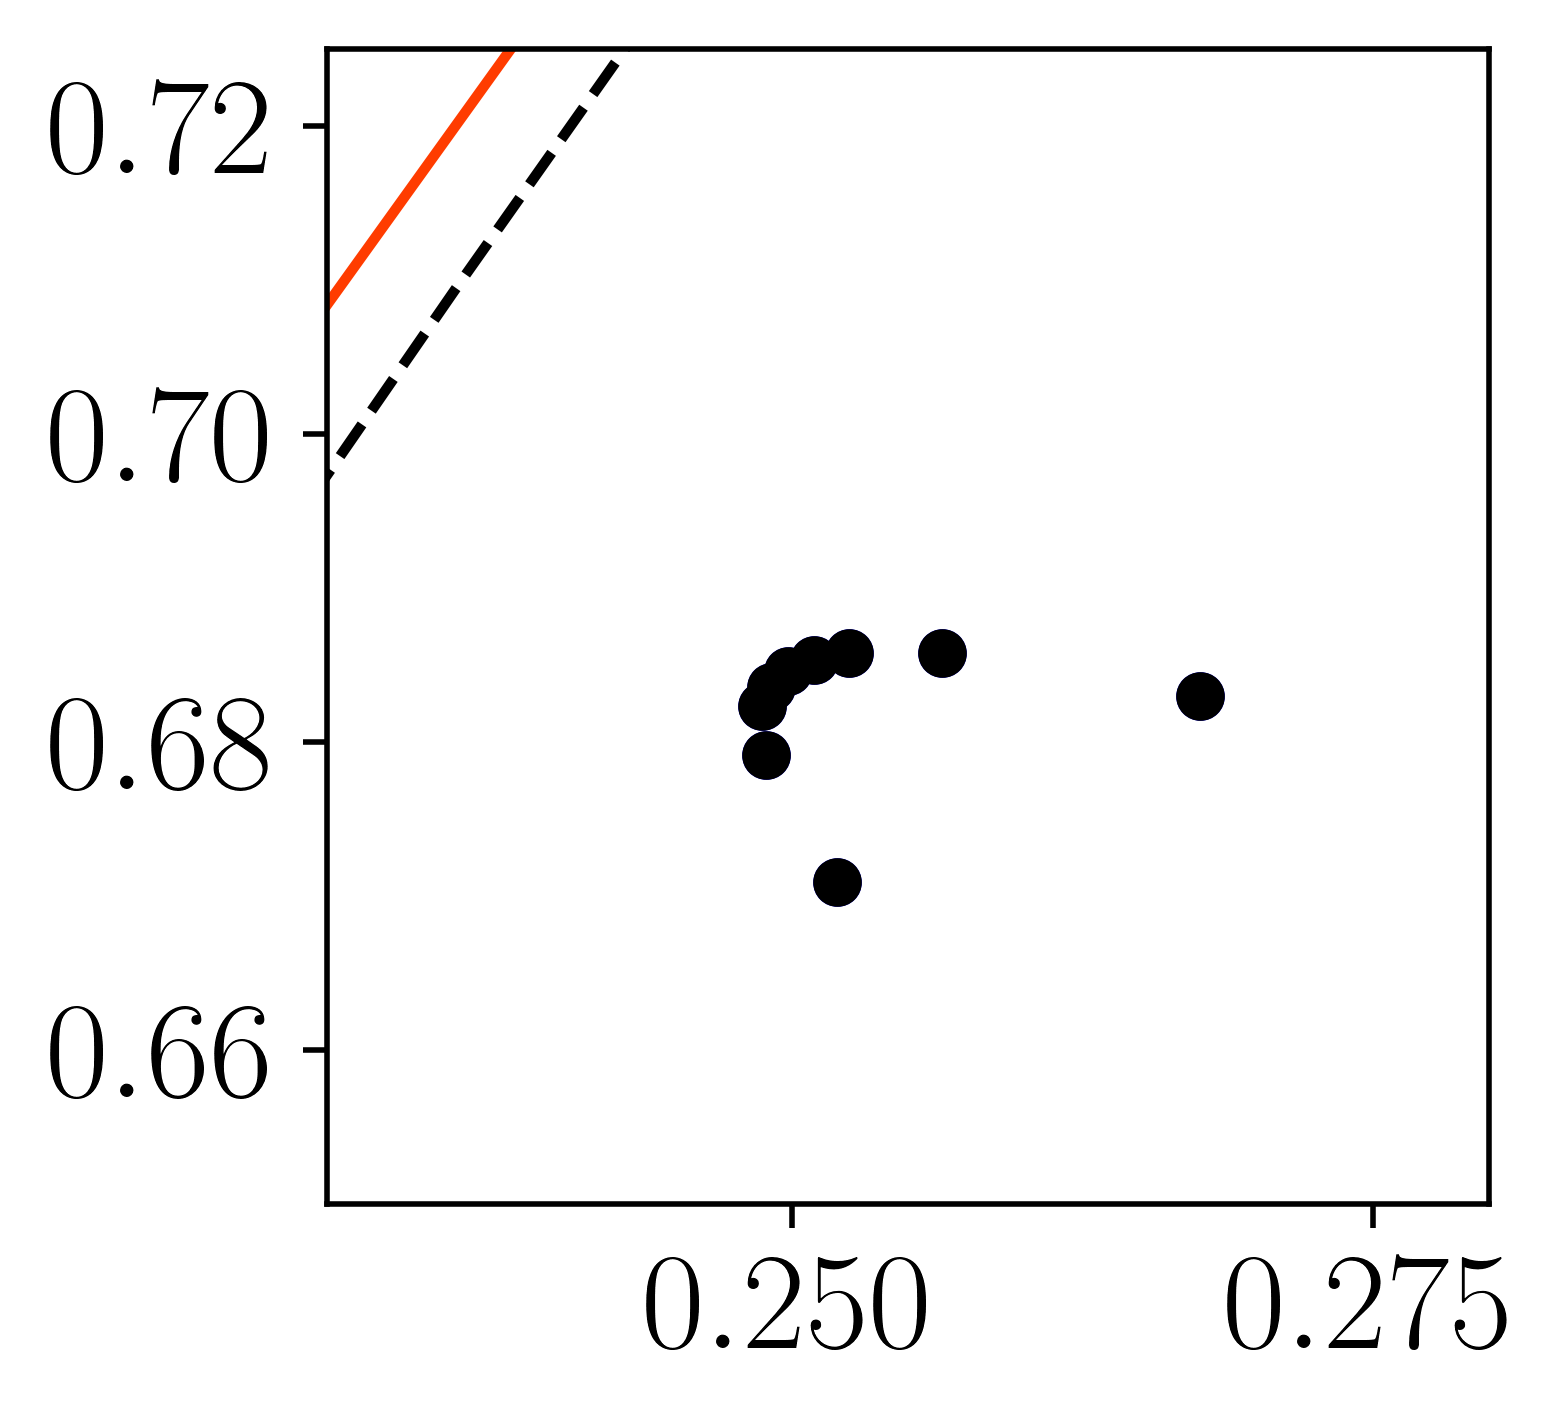

In [53]:

a_mom = np.linspace(0,0.75,50)
ct_mom = 4 * a_mom * (1 - a_mom)

ct_mad = np.linspace(0,1.5,75)
k1 = 0.2460
k2 = 0.0586
k3 = 0.0883
a_mad = k3 * ct_mad**3 + k2 * ct_mad**2 + k1 * ct_mad

fig, ax = plt.subplots(figsize=(3, 3))

ax.plot(a_mom,ct_mom,'#ff3c00')
ax.plot(a_mad,ct_mad,'k--')
ax.scatter(wrf_ind,wrf_cot,color='b')

ax.scatter(A_pred,wrf_cot,color='k')

ax.set_xlim([0.23,0.28])
ax.set_ylim([0.65,0.725])

In [90]:
wrf_ind

array([0.25194899, 0.24890544, 0.24874281, 0.24912277, 0.24985269,
       0.25097282, 0.25247105, 0.25648237, 0.26755682])

In [91]:
wrf_cot

array([0.67091542, 0.6791683 , 0.68235704, 0.68362027, 0.6846248 ,
       0.68534165, 0.68577385, 0.68579657, 0.68300942])

In [92]:
A_pred

array([0.25194899, 0.24890544, 0.24874281, 0.24912277, 0.2498527 ,
       0.25097282, 0.25247105, 0.25648237, 0.26755682])